## 1.1 Random number generators


In [8]:
import numpy as np
try:
    from numba import njit
    _NUMBA = True
except ImportError:
    _NUMBA = False
    def njit(fn): 
        return fn

@njit
def randu(seed, n):
    """Generate n RANDU pseudo-random numbers in [0, 1].
    """
    a = np.int64(65539)
    m = np.int64(2**31)

    seed = np.int64(seed)
    if seed % 2 == 0:
        raise ValueError("RANDU must be initialized with an odd integer seed.")

    states = np.empty(n, dtype=np.int64)
    values = np.empty(n, dtype=np.float64)

    x = seed
    for i in range(n):
        x = (a * x) % m
        states[i] = x
        values[i] = x / 2147483648.0 

    return states, values

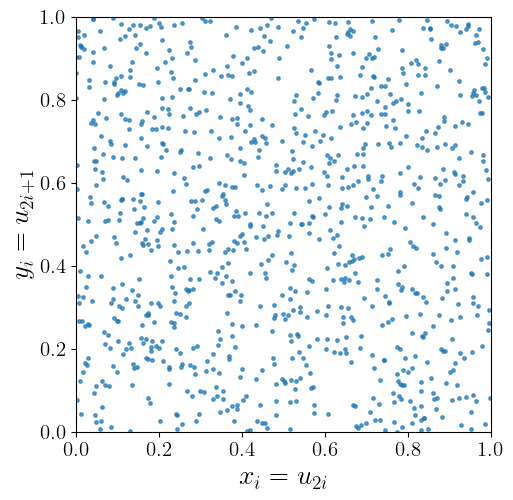

In [9]:

import matplotlib.pyplot as plt
import shutil

fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({'font.size': fontsi})

# Build successive 2-tuples (x_i, y_i) = (u_{2i}, u_{2i+1})
n_pairs = 1000
seed = 12345  # odd seed
_, u_pairs_source = randu(seed=seed, n=2 * n_pairs)

x = u_pairs_source[0::2]
y = u_pairs_source[1::2]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, s=6, alpha=0.7)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$x_i = u_{2i}$', fontsize=fontsi2)
ax.set_ylabel(r'$y_i = u_{2i+1}$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
fig.subplots_adjust(left=0.14, right=0.97, bottom=0.12, top=0.97)
plt.savefig('./sheet1_output/randu_pairs.pdf')
plt.show()

## a)

Visual check: the point cloud is not fully uniform; one can already see band/structure patterns, which is unusual for a good pseudo-random generator.

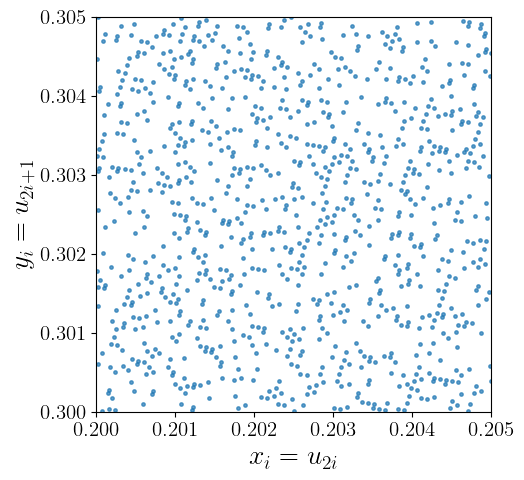

In [10]:
# Zoom test: keep collecting until the zoomed window again contains ~n_pairs points
x_lo, x_hi = 0.2, 0.205
y_lo, y_hi = 0.3, 0.305
target_inside = n_pairs  # same order of points as in the first scatter (about 1000)

area_zoom = (x_hi - x_lo) * (y_hi - y_lo)
expected_pairs_for_uniform = int(np.ceil(target_inside / area_zoom))

# Continue RANDU sequence in chunks until enough points fall into the window
state = np.int64(seed)

x_zoom_list = []
y_zoom_list = []
tested_pairs = 0
chunk_pairs = 300_000  # 600,000 RANDU numbers per chunk
max_pairs = 120_000_000

while len(x_zoom_list) < target_inside and tested_pairs < max_pairs:
    states_chunk, u_chunk = randu(seed=int(state), n=2 * chunk_pairs)
    state = states_chunk[-1]
    x_chunk = u_chunk[0::2]
    y_chunk = u_chunk[1::2]

    mask = (x_chunk >= x_lo) & (x_chunk <= x_hi) & (y_chunk >= y_lo) & (y_chunk <= y_hi)
    if np.any(mask):
        x_zoom_list.extend(x_chunk[mask].tolist())
        y_zoom_list.extend(y_chunk[mask].tolist())

    tested_pairs += chunk_pairs

x_zoom = np.array(x_zoom_list[:target_inside])
y_zoom = np.array(y_zoom_list[:target_inside])


fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_zoom, y_zoom, s=6, alpha=0.7)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$x_i = u_{2i}$', fontsize=fontsi2)
ax.set_ylabel(r'$y_i = u_{2i+1}$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
fig.subplots_adjust(left=0.18, right=0.97, bottom=0.12, top=0.97)
plt.savefig('./sheet1_output/randu_zoom.pdf')



## b)

Interpretation: the points still do not fill the window uniformly they remain arranged in visible bands/lines, showing strong correlation in RANDU outputs.

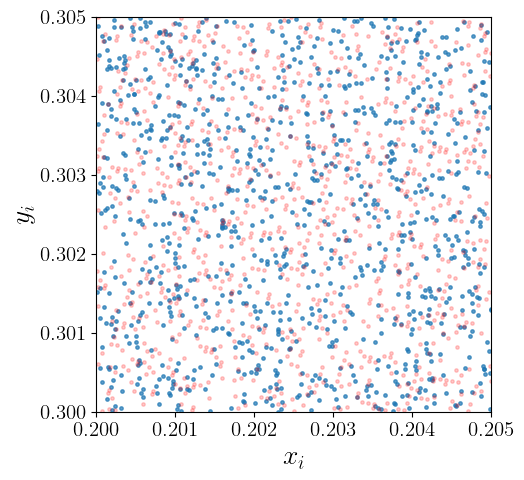

In [11]:

# Repeat the zoom test with NumPy's RNG for comparison
rng_np = np.random.default_rng(12345)

# Keep the same zoom window and target count as above
x_lo_np, x_hi_np = x_lo, x_hi
y_lo_np, y_hi_np = y_lo, y_hi
target_inside_np = target_inside

area_zoom_np = (x_hi_np - x_lo_np) * (y_hi_np - y_lo_np)
expected_pairs_uniform_np = int(np.ceil(target_inside_np / area_zoom_np))

x_zoom_np_list = []
y_zoom_np_list = []
tested_pairs_np = 0
chunk_pairs_np = 300_000
max_pairs_np = 120_000_000

while len(x_zoom_np_list) < target_inside_np and tested_pairs_np < max_pairs_np:
    x_chunk_np = rng_np.random(chunk_pairs_np)
    y_chunk_np = rng_np.random(chunk_pairs_np)

    mask_np = (x_chunk_np >= x_lo_np) & (x_chunk_np <= x_hi_np) & (y_chunk_np >= y_lo_np) & (y_chunk_np <= y_hi_np)
    if np.any(mask_np):
        x_zoom_np_list.extend(x_chunk_np[mask_np].tolist())
        y_zoom_np_list.extend(y_chunk_np[mask_np].tolist())

    tested_pairs_np += chunk_pairs_np

x_zoom_np = np.array(x_zoom_np_list[:target_inside_np])
y_zoom_np = np.array(y_zoom_np_list[:target_inside_np])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_zoom_np, y_zoom_np, s=6, alpha=0.7)
ax.scatter(x_zoom, y_zoom, s=6, alpha=0.2, color = "red")
ax.set_xlim(x_lo_np, x_hi_np)
ax.set_ylim(y_lo_np, y_hi_np)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'$x_i$', fontsize=fontsi2)
ax.set_ylabel(r'$y_i$', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
fig.subplots_adjust(left=0.18, right=0.97, bottom=0.12, top=0.97)
plt.savefig('./sheet1_output/numpy_rng_zoom.pdf')
plt.show()


## c)

[NumPy RNG] points fill the window much more uniformly without visible line/band artifacts,
which is what we expect from a good modern pseudo-random generator.


## 1.2: Fitting a line is simple!

Dataset: data/counts.txt
Number of points: 100
True model: a = 2.0000, b = 3.0000

Wrong fit (Gaussian chi2 with provided sigma):
  a = 2.0020 +/- 0.1317
  b = 1.6833 +/- 0.6643

Correct fit (Poisson likelihood):
  a = 2.0074 +/- 0.0765
  b = 2.7595 +/- 0.0354

Difference (wrong - correct):
 relative Delta a = -0.0706
 relative Delta b = -30.4100


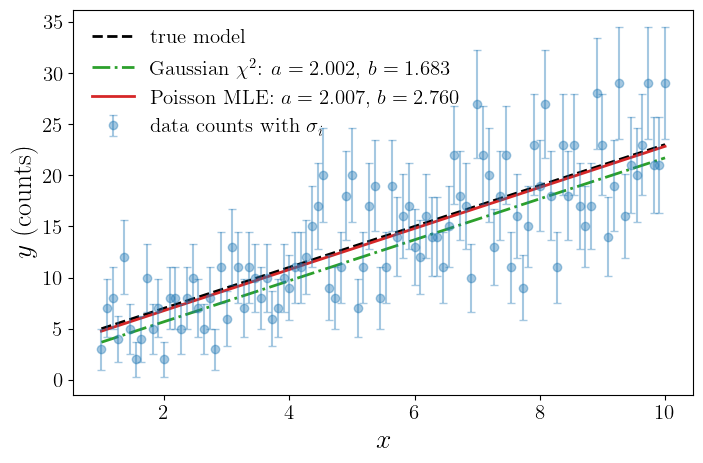

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize, curve_fit


data_path = Path('data/counts.txt')

raw = np.loadtxt(data_path, comments='#')
x4 = raw[:, 0]
y4 = raw[:, 1]
sigma4 = raw[:, 2]

# True model used to generate the provided dataset
a_true4 = 2.0
b_true4 = 3.0

# ── Wrong fit: Gaussian chi2 using provided sigma column ───────────────────
def linear_model(x, a, b):
    return a * x + b

popt_wrong, pcov_wrong = curve_fit(
    linear_model,
    x4,
    y4,
    p0=[1.0, 1.0],
    sigma=sigma4,
    absolute_sigma=True
)
a_wrong4, b_wrong4 = popt_wrong
a_wrong4_err, b_wrong4_err = np.sqrt(np.diag(pcov_wrong))

# ── Correct fit: Poisson maximum likelihood ─────────────────────────────────
def neg_poisson_ll(theta, x, y):
    """Negative Poisson log-likelihood for lambda = a*x + b."""
    a, b = theta
    lam = np.maximum(a * x + b, 1e-9)
    return -np.sum(y * np.log(lam) - lam)

result_correct4 = minimize(
    neg_poisson_ll,
    x0=np.array([a_wrong4, b_wrong4]),
    args=(x4, y4),
    method='BFGS'
)
a_correct4, b_correct4 = result_correct4.x

cov_correct4 = np.asarray(result_correct4.hess_inv)
a_correct4_err, b_correct4_err = np.sqrt(np.diag(cov_correct4))

print(f'Dataset: {data_path}')
print(f'Number of points: {len(x4)}')
print(f'True model: a = {a_true4:.4f}, b = {b_true4:.4f}')
print()
print('Wrong fit (Gaussian chi2 with provided sigma):')
print('  a = {:.4f} +/- {:.4f}'.format(a_wrong4, a_wrong4_err))
print('  b = {:.4f} +/- {:.4f}'.format(b_wrong4, b_wrong4_err))
print()
print('Correct fit (Poisson likelihood):')
print('  a = {:.4f} +/- {:.4f}'.format(a_correct4, a_correct4_err))
print('  b = {:.4f} +/- {:.4f}'.format(b_correct4, b_correct4_err))
print()
print('Difference (wrong - correct):')
print(' relative Delta a = {:.4f}'.format((a_wrong4 - a_correct4)/a_correct4_err))
print(' relative Delta b = {:.4f}'.format((b_wrong4 - b_correct4)/b_correct4_err))

# ── Plot ───────────────────────────────────────────────────────────────────
x_p4 = np.linspace(x4.min(), x4.max(), 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x4, y4, yerr=sigma4,
    fmt='o', color='tab:blue', capsize=3, zorder=5,
    label=r'data counts with $\sigma_i$',
    alpha = .4
)
ax.plot(x_p4, a_true4 * x_p4 + b_true4, 'k--', lw=2, label='true model')
ax.plot(
    x_p4, a_wrong4 * x_p4 + b_wrong4,
    color='tab:green', lw=2, ls='-.',
    label=rf'Gaussian $\chi^2$: $a={a_wrong4:.3f}$, $b={b_wrong4:.3f}$'
)
ax.plot(
    x_p4, a_correct4 * x_p4 + b_correct4,
    color='tab:red', lw=2,
    label=rf'Poisson MLE: $a={a_correct4:.3f}$, $b={b_correct4:.3f}$'
)
ax.set_xlabel(r'$x$', fontsize=fontsi2)
ax.set_ylabel(r'$y$ (counts)', fontsize=fontsi2)
ax.tick_params(labelsize=fontsi)
ax.legend(frameon=False, fontsize=fontsi)
plt.savefig('./sheet1_output/wrong_likelihood.pdf')
plt.show()


### Why the Gaussian fit is biased

The measurements are counts, so each point is modelled as
$$
y_i \sim \mathrm{Poisson}(\lambda_i), \qquad \lambda_i = a x_i + b,
$$
with variance tied to the mean: $\mathrm{Var}(y_i)=\lambda_i$.

A Gaussian weighted fit minimizes
$$
\chi^2(a,b)=\sum_i \frac{(y_i-(a x_i+b))^2}{\sigma_i^2},
$$
and assumes Gaussian residuals with known, fixed errors.

In this exercise, $\sigma_i$ is built from the observed counts (roughly $\sqrt{y_i+1}$), so the weights depend on the same noisy data being fit. Downward fluctuations get smaller $\sigma_i$ and are over-weighted, while upward fluctuations get larger $\sigma_i$ and are under-weighted. That asymmetric weighting shifts the best-fit parameters.


# 1.3: Questions

---

**1. What is a Venn diagram?**

A Venn diagram is a visual representation of sets and their relationships within a universal set.

---

**2. State De Morgan's laws and prove one of them with Venn diagrams.**

De Morgan's laws state:

$$\overline{A \cup B} = \bar{A} \cap \bar{B}$$

$$\overline{A \cap B} = \bar{A} \cup \bar{B}$$

For the proof see lecture notes.

---

**3. What types of randomness occur in a measurement?**

Two fundamental types arise:

- **statistical uncertainty:** Intrinsic, irreducible randomness inherent to the physical process itself (e.g. quantum fluctuations, photon shot noise). No amount of improved instrumentation can eliminate it.
- **systematic uncertainty:** Randomness due to incomplete knowledge, limited precision of instruments, calibration errors, or model assumptions. In principle reducible with better data or methods.

---

**4. What is a partition of the sample space $\Omega$? Give an astrophysical example.**

A collection of sets $\{B_i\}$ is a **partition** of $\Omega$ if:

1. The sets are mutually exclusive: $B_i \cap B_j = \emptyset$ for $i \neq j$
2. They are exhaustive: $\bigcup_i B_i = \Omega$

That is, every outcome in $\Omega$ belongs to exactly one $B_i$.

**Astrophysical example:** Classifying all observed galaxies by morphological type — elliptical (E), lenticular (S0), spiral (S), and irregular (Irr). Every galaxy falls into exactly one category, and together they cover all galaxies in the sample. The Hubble sequence forms a partition of the sample space of observed galaxies.

---

**5. What are the Kolmogorov axioms?**

**Axiom 1 (Non-negativity):**
$$P(A) \geq 0 \quad \text{for all } A \in \mathcal{F}$$

**Axiom 2 (Normalization):**
$$P(\Omega) = 1$$

**Axiom 3 ($\sigma$-additivity):** For any countable collection of mutually exclusive events $A_1, A_2, \ldots$ (with $A_i \cap A_j = \emptyset$ for $i \neq j$):
$$P\!\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i)$$

---

**6. Define conditional probability.**

The conditional probability of event $A$ given that event $B$ has occurred (with $P(B) > 0$) is:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

Intuitively, conditioning on $B$ restricts the sample space to $B$, and we ask what fraction of that restricted space is also covered by $A$.

---

**7. Define the joint PDF of a 3-dimensional continuous random variable.**

The probability of the vector lying in a region $\mathcal{R} \subseteq \mathbb{R}^3$ is then:

$$P\!\left((X_1,X_2,X_3)\in\mathcal{R}\right) = \iiint_{\mathcal{R}} f(x_1,x_2,x_3)\, dx_1\, dx_2\, dx_3$$

with the normalization condition $\iiint_{\mathbb{R}^3} f(x_1,x_2,x_3)\, dx_1\, dx_2\, dx_3 = 1$.

---

**8. How does the PDF of a continuous random variable relate to the probability?**

The PDF $f_X(x)$ is not itself a probability, but rather a probability density* The probability that $X$ falls in an interval $[a, b]$ is obtained by integration:

$$P(a \leq X \leq b) = \int_a^b f_X(x)\, dx$$

The PDF is related to the cumulative distribution function (CDF) $F_X(x) = P(X \leq x)$ by:

$$f_X(x) = \frac{dF_X}{dx}$$

Note that $f_X(x) \geq 0$ everywhere, and $\int_{-\infty}^{\infty} f_X(x)\, dx = 1$, but $f_X(x)$ itself can exceed 1.

---

**9. In what case do you add/multiply probabilities?**

 **add** probabilities when asking "either/or" (union of exclusive events); **multiply** when asking "both/and" (intersection, especially for independent events).

---

**10. What are marginal probability distributions?**

Given a joint distribution of two (or more) random variables, the **marginal distribution** of one variable is obtained by integrating (continuous case) or summing (discrete case) over all values of the other variable(s).

The marginal distribution $f_X(x)$ describes the distribution of $X$ alone, regardless of the value of $Y$. Geometrically, marginalizing "projects" the joint distribution onto one axis, collapsing all information about the other variable.